In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
from wordcloud import STOPWORDS
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

In [3]:
df1=pd.read_csv("/content/dreaddit_StressAnalysis.csv")

In [4]:
print("Row: ", df1.shape [0])
print("Columns: ", df1.shape [1])
print()
print("Catagorical columns: ")
print (df1.select_dtypes(include=['object']). apply(pd.Series.nunique, axis=0))
print ()
print ("Description :")
print (df1.info())
print ()
print ("Null: ")
print (df1.isnull().sum())

Row:  715
Columns:  116

Catagorical columns: 
subreddit          10
post_id           586
sentence_range    111
text              715
dtype: int64

Description :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 715 entries, 0 to 714
Columns: 116 entries, id to sentiment
dtypes: float64(106), int64(6), object(4)
memory usage: 648.1+ KB
None

Null: 
id                          0
subreddit                   0
post_id                     0
sentence_range              0
text                        0
                           ..
lex_dal_avg_pleasantness    0
social_upvote_ratio         0
social_num_comments         0
syntax_fk_grade             0
sentiment                   0
Length: 116, dtype: int64


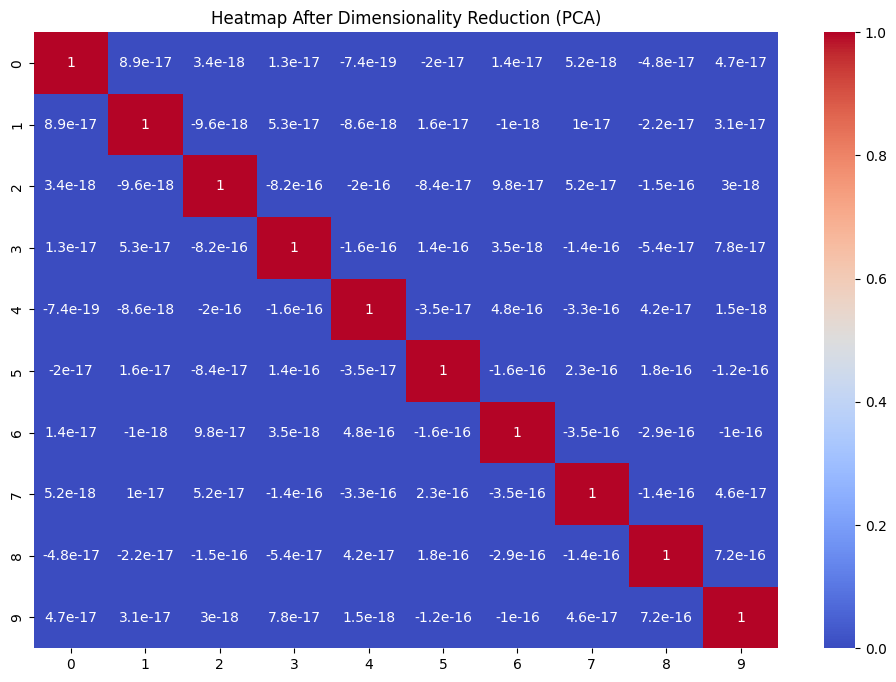

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=10)
reduced_data = pca.fit_transform(df1.select_dtypes(include=['float64', 'int64']))


reduced_corr = pd.DataFrame(reduced_data).corr()
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(reduced_corr, cmap="coolwarm", annot=True)
plt.title("Heatmap After Dimensionality Reduction (PCA)")
plt.show()

In [6]:
print ("Positive Sentiment:")
print(TextBlob("the greatest").polarity )
print()
print(TextBlob("the greatest").sentiment)


Positive Sentiment:
1.0

Sentiment(polarity=1.0, subjectivity=1.0)


In [7]:
print (" Nagative Sentiment:")
print (TextBlob("the worst").polarity)
print ()
print (TextBlob("the worst").sentiment)

 Nagative Sentiment:
-1.0

Sentiment(polarity=-1.0, subjectivity=1.0)


In [8]:
def detect_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

In [9]:
df2=df1[["text"]]

In [10]:
df2.head()

,text
0,"Its like that, if you want or not.“ ME: I have..."
1,I man the front desk and my title is HR Custom...
2,We'd be saving so much money with this new hou...
3,"My ex used to shoot back with ""Do you want me ..."
4,I haven’t said anything to him yet because I’m...


In [11]:
df2["sentiment"]=df2["text"].apply(detect_sentiment)


In [12]:
df2.head()

,text,sentiment
0,"Its like that, if you want or not.“ ME: I have...",0.000000
1,I man the front desk and my title is HR Custom...,-0.065909
2,We'd be saving so much money with this new hou...,-0.036818
3,"My ex used to shoot back with ""Do you want me ...",-0.066667
4,I haven’t said anything to him yet because I’m...,0.141667


In [13]:
print("Minium Sentiment :", df2["sentiment"].min())
print("Maxium Sentiment :", df2["sentiment"].max())
print (df2.sentiment.value_counts())

Minium Sentiment : -1.0
Maxium Sentiment : 0.8
sentiment
 0.000000    22
 0.150000     5
-0.100000     4
 0.125000     4
-0.133333     4
             ..
 0.445671     1
 0.142857     1
 0.071429     1
 0.194444     1
 0.265625     1
Name: count, Length: 635, dtype: int64


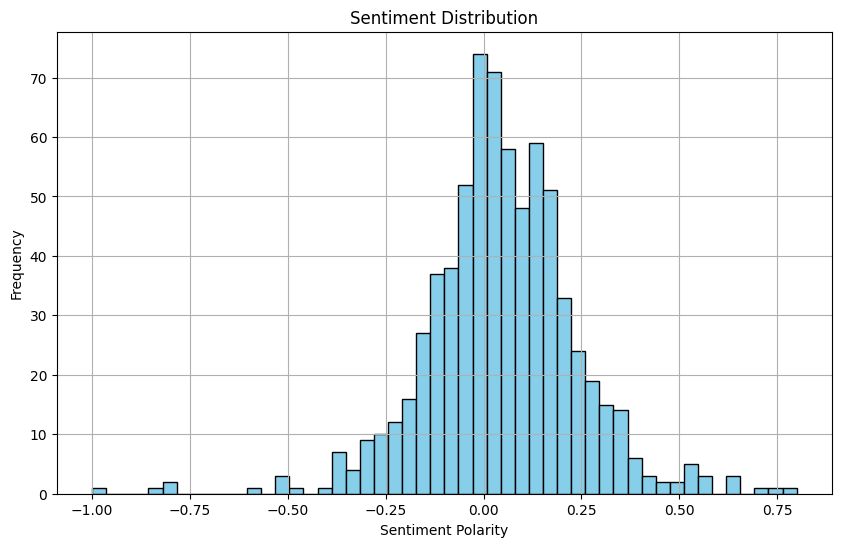

In [14]:
import matplotlib.pyplot as plt

df2["sentiment"].hist(bins=50, figsize=(10, 6), color="skyblue", edgecolor="black")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()

In [15]:
df2['text']

,text
0,"Its like that, if you want or not.“ ME: I have..."
1,I man the front desk and my title is HR Custom...
2,We'd be saving so much money with this new hou...
3,"My ex used to shoot back with ""Do you want me ..."
4,I haven’t said anything to him yet because I’m...
...,...
710,i have horrible vivid nightmares every night. ...
711,Also I can't think about both of them without ...
712,"Furthermore, I told him before we got really s..."
713,Here's the link to my amazon wish list where t...


In [16]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [17]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.tokenize import word_tokenize
import re
import string
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english')).union(set(ENGLISH_STOP_WORDS))

import re
import string
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

def preprocess_text(text):

    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r"#\w+", '', text)
    text = re.sub(r"@\w+", '', text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", '', text)
    text = ' '.join([stemmer.stem(word) for word in word_tokenize(text)])

    return text

In [18]:
import nltk
nltk.download('punkt_tab')
df2 ["text"]= df2["text"].apply(preprocess_text)
df2 ["text"]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text
0,it like that if you want or not “ me i have no...
1,i man the front desk and my titl is hr custom ...
2,wed be save so much money with thi new housrit...
3,my ex use to shoot back with do you want me to...
4,i haven ’ t said anyth to him yet becaus i ’ m...
...,...
710,i have horribl vivid nightmar everi night some...
711,also i cant think about both of them without g...
712,furthermor i told him befor we got realli seri...
713,here the link to my amazon wish list where the...


In [19]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
def wc(data, bgcolor='white'):
    plt.figure(figsize=(10, 10))
    wordcloud = WordCloud(
        background_color=bgcolor,
        stopwords=STOPWORDS,
        width=800,
        height=800
    ).generate(' '.join(data))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()


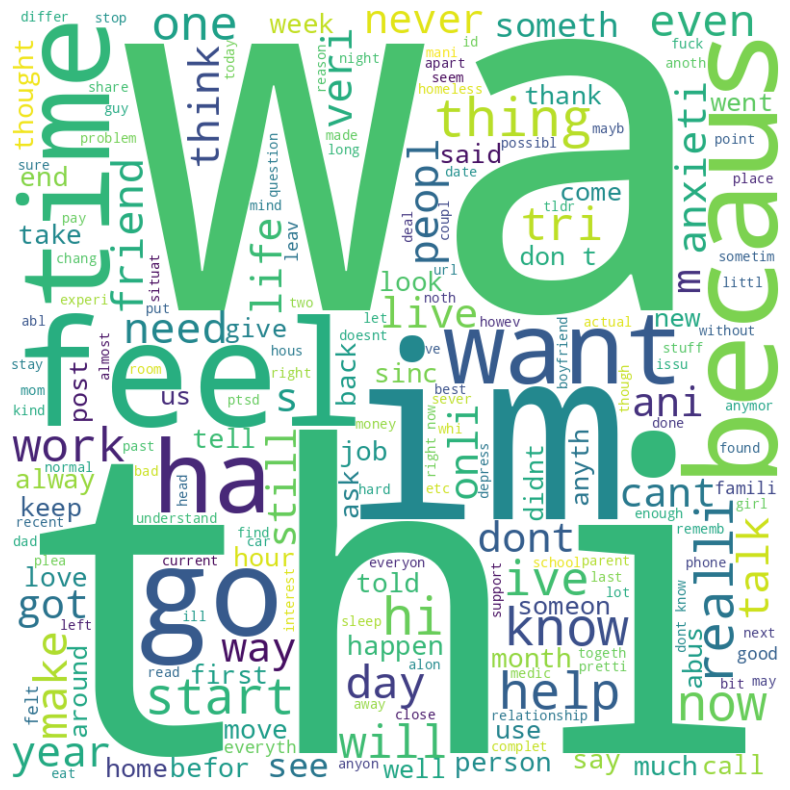

In [20]:
wc(df2['text'], bgcolor='white')


In [21]:
df2["sentiment_1"] = df2["text"].apply(detect_sentiment)
df2.head()

,text,sentiment,sentiment_1
0,it like that if you want or not “ me i have no...,0.000000,0.000000
1,i man the front desk and my titl is hr custom ...,-0.065909,-0.190909
2,wed be save so much money with thi new housrit...,-0.036818,-0.027273
3,my ex use to shoot back with do you want me to...,-0.066667,0.079167
4,i haven ’ t said anyth to him yet becaus i ’ m...,0.141667,0.225000


In [22]:
print("Minium Sentiment :", df2["sentiment_1"].min())
print("Maxium Sentiment :", df2["sentiment_1"].max())
print (df2.sentiment_1.value_counts())

Minium Sentiment : -0.8
Maxium Sentiment : 0.8
sentiment_1
 0.000000    30
 0.250000    13
 0.200000     8
 0.125000     5
 0.136364     5
             ..
 0.310000     1
 0.240000     1
-0.240000     1
-0.226852     1
 0.140758     1
Name: count, Length: 567, dtype: int64


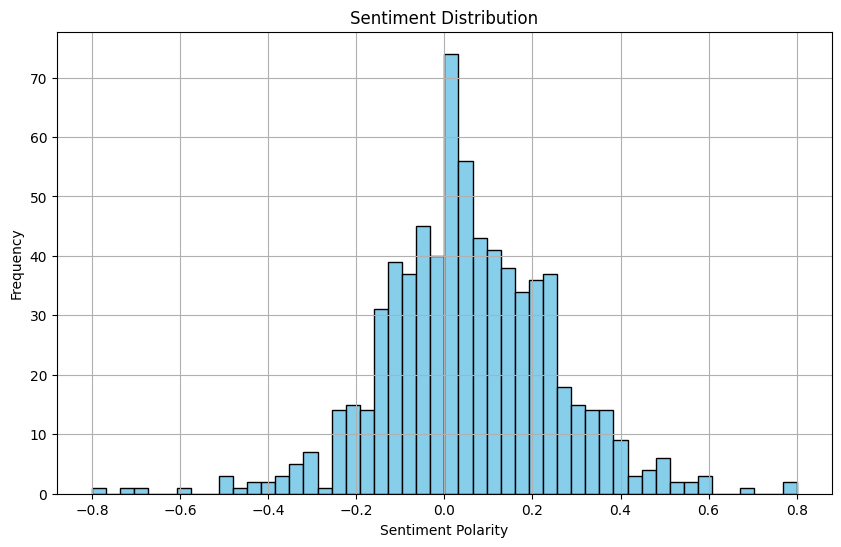

In [23]:
import matplotlib.pyplot as plt

df2["sentiment_1"].hist(bins=50, figsize=(10, 6), color="skyblue", edgecolor="black")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()

In [24]:
correlation = df2["sentiment"].corr(df2["sentiment_1"])
print("Correlation between sentiment and sentiment_1:", correlation)

Correlation between sentiment and sentiment_1: 0.7284738342897108


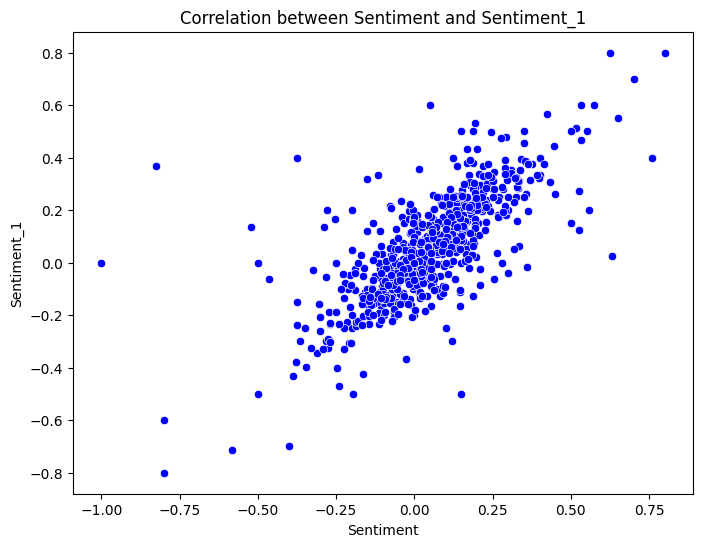

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df2["sentiment"], y=df2["sentiment_1"], color="blue")
plt.title("Correlation between Sentiment and Sentiment_1")
plt.xlabel("Sentiment")
plt.ylabel("Sentiment_1")
plt.show()

In [26]:
df2["sentiment_diff"] = abs(df2["sentiment"] - df2["sentiment_1"])
outliers = df2[df2["sentiment_diff"] > 0.5]
outliers

,text,sentiment,sentiment_1,sentiment_diff
140,she ’ s in play therapi onc a week but haven ’...,-0.375000,0.400000,0.775000
158,i assum she would answer the question or she w...,0.050000,0.600000,0.550000
437,3 i wa meet with someon 4 becaus i ’ m so tire...,-0.522222,0.136364,0.658586
474,they look noth like my growth she told me i wa...,-1.000000,0.000000,1.000000
497,tomorrow i buri my best friend who tragic pass...,0.631250,0.025000,0.606250
572,i know after we talk ill be abl to speak with ...,0.150000,-0.500000,0.650000
619,it is quit annoy i get diarrhea when i get pan...,-0.825000,0.366667,1.191667


In [27]:
df2["combined_sentiment"] = (df2["sentiment"] + df2["sentiment_1"]) / 2
df2.head()

,text,sentiment,sentiment_1,sentiment_diff,combined_sentiment
0,it like that if you want or not “ me i have no...,0.000000,0.000000,0.000000,0.000000
1,i man the front desk and my titl is hr custom ...,-0.065909,-0.190909,0.125000,-0.128409
2,wed be save so much money with thi new housrit...,-0.036818,-0.027273,0.009545,-0.032045
3,my ex use to shoot back with do you want me to...,-0.066667,0.079167,0.145833,0.006250
4,i haven ’ t said anyth to him yet becaus i ’ m...,0.141667,0.225000,0.083333,0.183333


In [28]:
df2["combined_sentiment"].iloc[[140, 158, 437,474,497,572,619]]

,combined_sentiment
140,0.012500
158,0.325000
437,-0.192929
474,-0.500000
497,0.328125
572,-0.175000
619,-0.229167


In [29]:
df2.loc[[140, 158, 437, 474, 497, 572, 619], 'sentiment_1'] = df2.loc[[140, 158, 437, 474, 497, 572, 619], 'combined_sentiment']
print ( df2["sentiment_1"].iloc[[140, 158, 437,474,497,572,619]])

140    0.012500
158    0.325000
437   -0.192929
474   -0.500000
497    0.328125
572   -0.175000
619   -0.229167
Name: sentiment_1, dtype: float64


In [30]:
def label_sentiment(value):
    if value < 0:
        return "Negative"
    else:
        return "Positive"
df2["sentiment_label"] = df2["sentiment_1"].apply(label_sentiment)
df2=df2[['text','sentiment_1','sentiment_label']]
df2.head()


,text,sentiment_1,sentiment_label
0,it like that if you want or not “ me i have no...,0.000000,Positive
1,i man the front desk and my titl is hr custom ...,-0.190909,Negative
2,wed be save so much money with thi new housrit...,-0.027273,Negative
3,my ex use to shoot back with do you want me to...,0.079167,Positive
4,i haven ’ t said anyth to him yet becaus i ’ m...,0.225000,Positive


In [31]:
print(df2["sentiment_label"].value_counts())

sentiment_label
Positive    449
Negative    266
Name: count, dtype: int64


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

tfidf = TfidfVectorizer(max_features=100)
text_features = tfidf.fit_transform(df2['text']).toarray()

df2['sentiment_1'] = df2['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [33]:
print(df2[['text', 'sentiment_1']].head())
print("Shape of TF-IDF features:", text_features.shape)

                                                text  sentiment_1
0  it like that if you want or not “ me i have no...     0.000000
1  i man the front desk and my titl is hr custom ...    -0.190909
2  wed be save so much money with thi new housrit...    -0.027273
3  my ex use to shoot back with do you want me to...     0.079167
4  i haven ’ t said anyth to him yet becaus i ’ m...     0.225000
Shape of TF-IDF features: (715, 100)


In [34]:
import numpy as np

combined_features = np.hstack([text_features, df2[['sentiment_1']].values])

print("Shape of combined features:", combined_features.shape)

Shape of combined features: (715, 101)


<Axes: xlabel='sentiment_label', ylabel='count'>

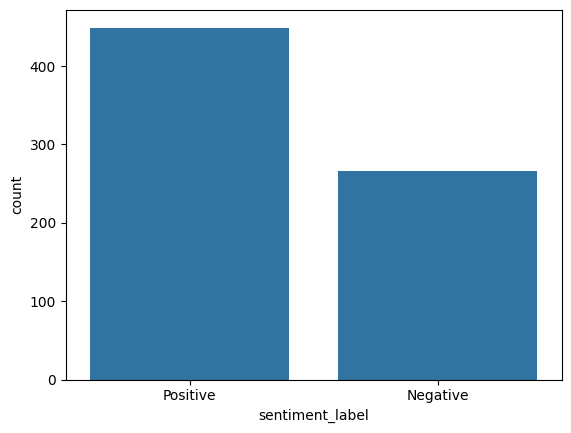

In [35]:
import seaborn as sns
sns.countplot(x='sentiment_label',data=df2)

In [36]:
df2=df2[['text','sentiment_label']]
df2['label']=df2['sentiment_label']. map({"Negative":0, "Positive": 1})
df2.head()

,text,sentiment_label,label
0,it like that if you want or not “ me i have no...,Positive,1
1,i man the front desk and my titl is hr custom ...,Negative,0
2,wed be save so much money with thi new housrit...,Negative,0
3,my ex use to shoot back with do you want me to...,Positive,1
4,i haven ’ t said anyth to him yet becaus i ’ m...,Positive,1


In [37]:
from sklearn.feature_extraction.text import CountVectorizer
vect=CountVectorizer(stop_words="english")
matrix=vect.fit_transform(df2.text).toarray()
x=matrix
y=df2["label"].values

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

x_train, x_test, y_train, y_test = train_test_split(
    combined_features, df2['label'], test_size=0.2, random_state=42
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

Confusion Matrix:
 [[50  6]
 [ 6 81]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        56
           1       0.93      0.93      0.93        87

    accuracy                           0.92       143
   macro avg       0.91      0.91      0.91       143
weighted avg       0.92      0.92      0.92       143

Accuracy: 0.916


In [39]:
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


def predict_new_text(model, tfidf, scaler, new_text):
    text_features = tfidf.transform([new_text]).toarray()
    sentiment = TextBlob(new_text).sentiment.polarity
    combined_features = np.hstack([text_features, np.array([[sentiment]])])

    combined_features = scaler.transform(combined_features)
    prediction = model.predict(combined_features)

    return prediction[0]

new_text = "I hate my self, i wannna die"
prediction = predict_new_text(model, tfidf, scaler, new_text)
print(f"Prediction for the new text: {prediction}")

Prediction for the new text: 0
